# Lab 4.2. LSTM для классификации активности по реальным временным рядам

В этом ноутбуке мы используем **LSTM** для классификации последовательностей на реальном датасете **Human Activity Recognition Using Smartphones** из UCI Machine Learning Repository.

Данные были записаны с акселерометра и гироскопа смартфона Samsung Galaxy S II, закрепленного на поясе. Участники выполняли 6 активностей:

- walking;
- walking upstairs;
- walking downstairs;
- sitting;
- standing;
- laying.

Каждый объект в датасете — это окно сенсорных измерений длиной 2.56 секунды: **128 временных шагов** при частоте 50 Hz. Для LSTM это естественный вход вида `[batch, seq_len, num_features]`.

## Импорт

In [5]:
import random
import urllib.request
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [6]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

## Загружаем UCI HAR Dataset

Ноутбук скачивает архив с UCI Repository и распаковывает его в папку `data/`. Если данные уже скачаны, повторная загрузка не выполняется.

In [7]:
DATA_URL = 'https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip'
DATA_DIR = Path('data')
OUTER_ZIP_PATH = DATA_DIR / 'uci_har.zip'
INNER_ZIP_PATH = DATA_DIR / 'UCI HAR Dataset.zip'
EXTRACTED_DIR = DATA_DIR / 'UCI HAR Dataset'

DATA_DIR.mkdir(exist_ok=True)

if not OUTER_ZIP_PATH.exists() and not INNER_ZIP_PATH.exists() and not EXTRACTED_DIR.exists():
    print('Downloading dataset...')
    urllib.request.urlretrieve(DATA_URL, OUTER_ZIP_PATH)

if not INNER_ZIP_PATH.exists() and not EXTRACTED_DIR.exists():
    print('Extracting outer archive...')
    with zipfile.ZipFile(OUTER_ZIP_PATH, 'r') as archive:
        archive.extractall(DATA_DIR)

if INNER_ZIP_PATH.exists() and not EXTRACTED_DIR.exists():
    print('Extracting UCI HAR Dataset archive...')
    with zipfile.ZipFile(INNER_ZIP_PATH, 'r') as archive:
        archive.extractall(DATA_DIR)

expected_file = EXTRACTED_DIR / 'train' / 'Inertial Signals' / 'body_acc_x_train.txt'
if not expected_file.exists():
    raise FileNotFoundError(
        f'Dataset was not extracted correctly. Expected file was not found: {expected_file}'
    )

print(EXTRACTED_DIR)

data/UCI HAR Dataset


## Что лежит в данных

В архиве есть два варианта представления:

- `X_train.txt` и `X_test.txt` — готовые табличные признаки, рассчитанные авторами датасета;
- `Inertial Signals/` — сами временные сигналы, разбитые на окна.

Для демонстрации LSTM нам нужны именно временные сигналы из `Inertial Signals/`, потому что LSTM должен видеть порядок измерений во времени.

В модели используются 9 каналов:

- `body_acc_x`, `body_acc_y`, `body_acc_z` — ускорение тела по осям X/Y/Z после отделения гравитационной компоненты;
- `body_gyro_x`, `body_gyro_y`, `body_gyro_z` — угловая скорость тела по осям X/Y/Z, измеренная гироскопом;
- `total_acc_x`, `total_acc_y`, `total_acc_z` — полное ускорение по осям X/Y/Z, то есть ускорение тела вместе с гравитационной компонентой.

Таким образом, каждый временной шаг описывается вектором из 9 признаков, а вся последовательность имеет форму `[128, 9]`.

In [ ]:
activity_labels = {
    1: 'WALKING',
    2: 'WALKING_UPSTAIRS',
    3: 'WALKING_DOWNSTAIRS',
    4: 'SITTING',
    5: 'STANDING',
    6: 'LAYING',
}

signal_names = [
    'body_acc_x', 'body_acc_y', 'body_acc_z',
    'body_gyro_x', 'body_gyro_y', 'body_gyro_z',
    'total_acc_x', 'total_acc_y', 'total_acc_z',
]

def load_split(split):
    split_dir = EXTRACTED_DIR / split
    signal_dir = split_dir / 'Inertial Signals'

    signals = []
    for name in signal_names:
        path = signal_dir / f'{name}_{split}.txt'
        signal = np.loadtxt(path)
        signals.append(signal)

    X = np.stack(signals, axis=-1).astype(np.float32)  # [samples, seq_len, channels]
    y = np.loadtxt(split_dir / f'y_{split}.txt', dtype=np.int64) - 1
    subjects = np.loadtxt(split_dir / f'subject_{split}.txt', dtype=np.int64)

    return X, y, subjects


X_train, y_train, subjects_train = load_split('train')
X_test, y_test, subjects_test = load_split('test')

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((7352, 128, 9), (7352,), (2947, 128, 9), (2947,))

Форма `X_train` должна быть примерно `[7352, 128, 9]`: 7352 окон, 128 временных шагов, 9 сенсорных каналов.

## Визуализируем несколько последовательностей

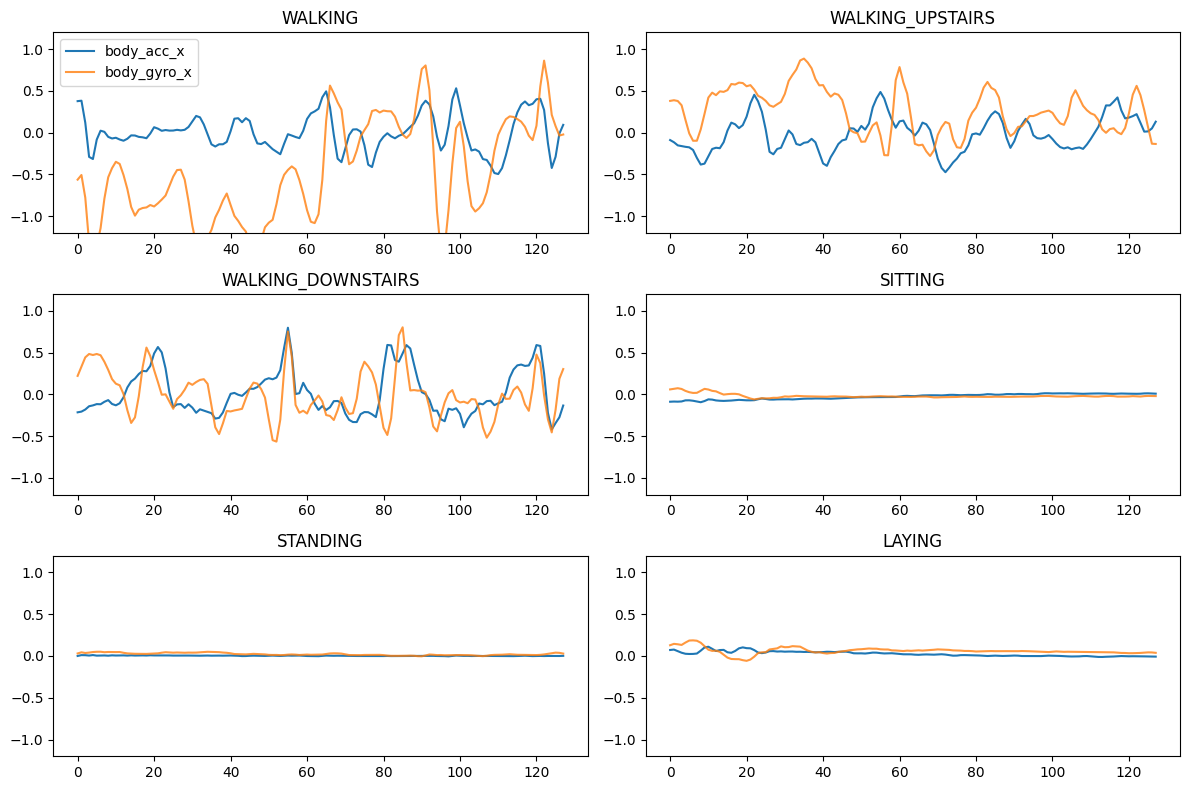

In [9]:
plt.figure(figsize=(12, 8))

for class_id in range(6):
    idx = np.where(y_train == class_id)[0][0]

    plt.subplot(3, 2, class_id + 1)
    plt.plot(X_train[idx, :, 0], label='body_acc_x')
    plt.plot(X_train[idx, :, 3], label='body_gyro_x', alpha=0.8)
    plt.title(activity_labels[class_id + 1])
    plt.ylim(-1.2, 1.2)

    if class_id == 0:
        plt.legend()

plt.tight_layout()

## Нормализация

Нормализуем каждый сенсорный канал по обучающей выборке. Статистики тестовой выборки при этом не используем, чтобы не подмешивать информацию из теста в обучение.

In [10]:
channel_mean = X_train.mean(axis=(0, 1), keepdims=True)
channel_std = X_train.std(axis=(0, 1), keepdims=True) + 1e-6

X_train_norm = (X_train - channel_mean) / channel_std
X_test_norm = (X_test - channel_mean) / channel_std

## DataLoader

In [11]:
X_train_tensor = torch.tensor(X_train_norm, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_norm, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

batch_size = 128

train_loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor),
    batch_size=batch_size,
    shuffle=True,
)

test_loader = DataLoader(
    TensorDataset(X_test_tensor, y_test_tensor),
    batch_size=batch_size,
)

len(train_loader), len(test_loader)

(58, 24)

## LSTM-классификатор

Для каждого окна LSTM обрабатывает 128 временных шагов. Последнее скрытое состояние можно интерпретировать как компактное представление всей последовательности. Затем полносвязный слой превращает это представление в 6 логитов классов.

In [ ]:
class LSTMActivityClassifier(nn.Module):
    def __init__(self, input_size=9, hidden_size=64, num_layers=1, num_classes=6, dropout=0.2):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
        )

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size, num_classes),
        )

    def forward(self, x):
        lstm_out, (_, _) = self.lstm(x)
        last_hidden = lstm_out[-1]
        return self.classifier(last_hidden)

## Модель, функция потерь и оптимизатор

Так как классов несколько и каждый пример принадлежит ровно одному классу, используем `CrossEntropyLoss`. Она ожидает сырые логиты, поэтому `softmax` внутри модели не нужен.

In [13]:
model = LSTMActivityClassifier().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)
num_parameters

19590

## Функции обучения и оценки

In [14]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        batch_size = len(yb)
        total_loss += loss.item() * batch_size
        total_correct += (logits.argmax(dim=1) == yb).sum().item()
        total_samples += batch_size

    return total_loss / total_samples, total_correct / total_samples


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits = model(xb)
        loss = criterion(logits, yb)

        batch_size = len(yb)
        total_loss += loss.item() * batch_size
        total_correct += (logits.argmax(dim=1) == yb).sum().item()
        total_samples += batch_size

    return total_loss / total_samples, total_correct / total_samples

## Обучение

In [15]:
history = {
    'train_loss': [],
    'train_acc': [],
    'test_loss': [],
    'test_acc': [],
}

epochs = 20

for epoch in range(1, epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    test_loss, test_acc = evaluate(model, test_loader, criterion)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)

    print(
        f'Epoch {epoch:02d} | '
        f'train loss: {train_loss:.4f}, train acc: {train_acc:.3f} | '
        f'test loss: {test_loss:.4f}, test acc: {test_acc:.3f}'
    )

Epoch 01 | train loss: 1.4817, train acc: 0.459 | test loss: 1.2110, test acc: 0.525
Epoch 02 | train loss: 0.9729, train acc: 0.590 | test loss: 0.7858, test acc: 0.638
Epoch 03 | train loss: 0.6896, train acc: 0.701 | test loss: 0.6827, test acc: 0.721
Epoch 04 | train loss: 0.5015, train acc: 0.826 | test loss: 1.0803, test acc: 0.638
Epoch 05 | train loss: 0.4609, train acc: 0.833 | test loss: 0.4620, test acc: 0.845
Epoch 06 | train loss: 0.2853, train acc: 0.914 | test loss: 0.3971, test acc: 0.878
Epoch 07 | train loss: 0.2288, train acc: 0.929 | test loss: 0.4320, test acc: 0.867
Epoch 08 | train loss: 0.2108, train acc: 0.934 | test loss: 0.3492, test acc: 0.884
Epoch 09 | train loss: 0.1815, train acc: 0.943 | test loss: 0.3731, test acc: 0.883
Epoch 10 | train loss: 0.1920, train acc: 0.937 | test loss: 0.6680, test acc: 0.842
Epoch 11 | train loss: 0.1958, train acc: 0.938 | test loss: 0.3315, test acc: 0.895
Epoch 12 | train loss: 0.1562, train acc: 0.945 | test loss: 0.33

На CPU обучение может занять несколько минут. Для демонстрации на занятии можно уменьшить `epochs` до 5–10: динамика качества все равно будет видна.

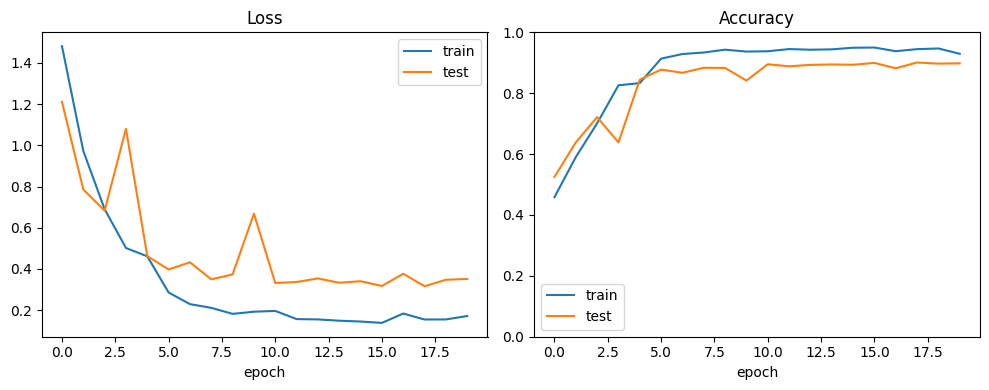

In [16]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='train')
plt.plot(history['test_loss'], label='test')
plt.title('Loss')
plt.xlabel('epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='train')
plt.plot(history['test_acc'], label='test')
plt.title('Accuracy')
plt.xlabel('epoch')
plt.ylim(0, 1.0)
plt.legend()

plt.tight_layout()

## Матрица ошибок

В HAR часто путаются пары похожих активностей: например, `SITTING` и `STANDING`, потому что в обоих случаях сигнал слабее, чем при ходьбе.

In [17]:
@torch.no_grad()
def predict_all(model, loader):
    model.eval()

    predictions = []
    targets = []

    for xb, yb in loader:
        logits = model(xb.to(device))
        predictions.append(logits.argmax(dim=1).cpu())
        targets.append(yb)

    return torch.cat(predictions), torch.cat(targets)


preds, targets = predict_all(model, test_loader)

num_classes = len(activity_labels)
confusion = torch.zeros(num_classes, num_classes, dtype=torch.int64)

for true_label, pred_label in zip(targets, preds):
    confusion[true_label, pred_label] += 1

confusion

tensor([[462,  23,  11,   0,   0,   0],
        [ 10, 444,  14,   0,   0,   3],
        [ 16,   7, 397,   0,   0,   0],
        [  1,   2,   0, 368, 120,   0],
        [  3,   0,   0,  63, 466,   0],
        [  0,  27,   0,   0,   0, 510]])

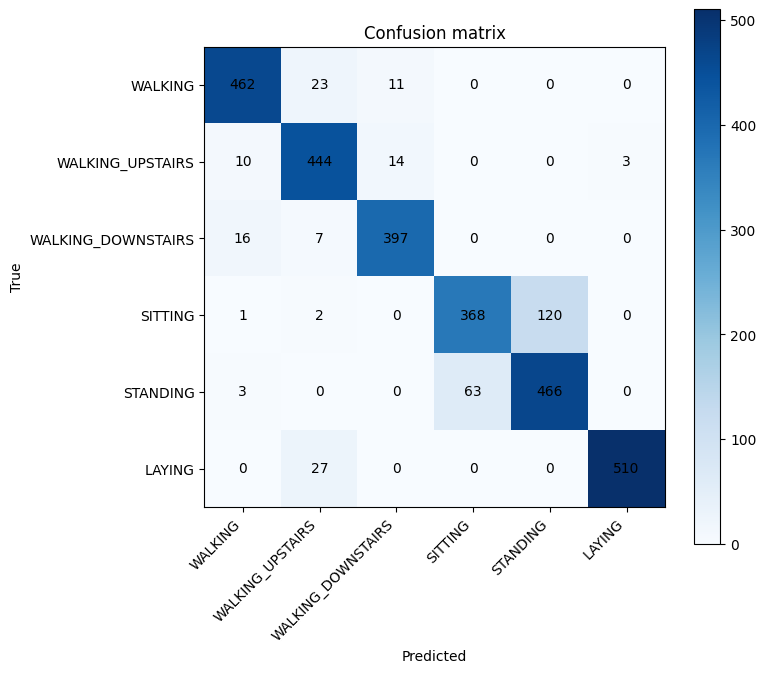

In [18]:
names = [activity_labels[i + 1] for i in range(num_classes)]

plt.figure(figsize=(8, 7))
plt.imshow(confusion, cmap='Blues')
plt.xticks(range(num_classes), names, rotation=45, ha='right')
plt.yticks(range(num_classes), names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion matrix')
plt.colorbar()

for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, confusion[i, j].item(), ha='center', va='center')

plt.tight_layout()

## Предсказание для одного окна

WALKING             : 0.004
WALKING_UPSTAIRS    : 0.000
WALKING_DOWNSTAIRS  : 0.000
SITTING             : 0.046
STANDING            : 0.950
LAYING              : 0.000


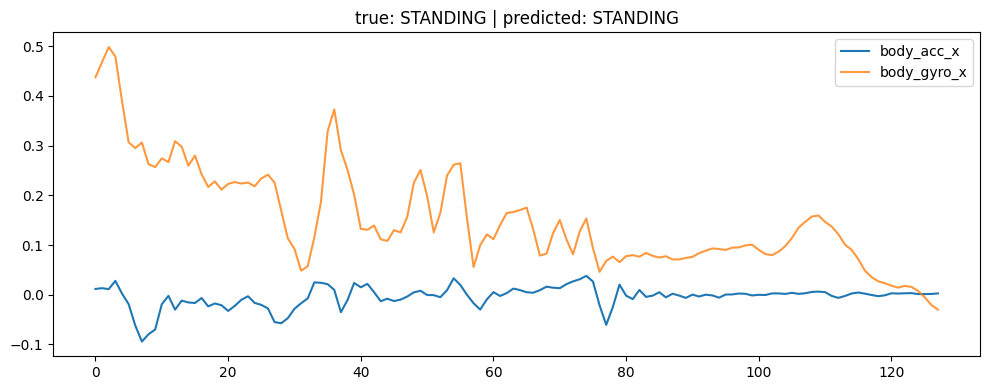

In [19]:
example_idx = 0
example = X_test_tensor[example_idx:example_idx + 1].to(device)

model.eval()
with torch.no_grad():
    logits = model(example)
    probabilities = torch.softmax(logits, dim=1).cpu().squeeze()
    predicted_class = probabilities.argmax().item()

true_class = y_test_tensor[example_idx].item()

plt.figure(figsize=(10, 4))
plt.plot(X_test[example_idx, :, 0], label='body_acc_x')
plt.plot(X_test[example_idx, :, 3], label='body_gyro_x', alpha=0.8)
plt.title(
    f'true: {activity_labels[true_class + 1]} | '
    f'predicted: {activity_labels[predicted_class + 1]}'
)
plt.legend()
plt.tight_layout()

for class_id, probability in enumerate(probabilities):
    print(f'{activity_labels[class_id + 1]:20s}: {probability:.3f}')